In [1]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing
We interpolate then normalize the data. Each is done individually

In [2]:
# Replace with your own files
#!cp "/content/drive/My Drive/ramandata/conor/Train_Inputs.mat" .
#!cp "/content/drive/My Drive/ramandata/conor/Test_Inputs.mat" .

In [3]:
import scipy.io
import os
import numpy as np
import h5py

file_path = '/content/drive/MyDrive/Tesi_Raman/Datasets/Paper RamanMAE/Dataset3A_Twist.mat'
print('Loading Dataset 3A (TWIST)...')

# 1. Loading and selecting variables
try:
    mat = scipy.io.loadmat(file_path)
    X_all_norm = mat['All_norm']
    labels = mat['All_class'].flatten()
    mice_ids = mat['All_mouse'].flatten()
    indici_validi = mat['All_index'].flatten() - 1  # In Python, indices start at 0

    if 'x_red' in mat and X_all_norm.shape[1] == len(mat['x_red'].flatten()):
        asse_X_orig = mat['x_red'].flatten()
        print("All_norm uses the x_red axis.")
    else:
        asse_X_orig = mat['x'].flatten()
        print("All_norm uses the full x axis.")
except Exception:
    # Fallback in case the file is in v7.3 format
    with h5py.File(file_path, 'r') as f:
        X_all_norm = np.array(f['All_norm']).T
        labels = np.array(f['All_class']).flatten()
        mice_ids = np.array(f['All_mouse']).flatten()
        indici_validi = np.array(f['All_index']).flatten().astype(int) - 1

        if 'x_red' in f and X_all_norm.shape[1] == len(np.array(f['x_red']).flatten()):
            asse_X_orig = np.array(f['x_red']).flatten()
            print("All_norm uses the x_red axis.")
        else:
            asse_X_orig = np.array(f['x']).flatten()
            print("All_norm uses the full x axis.")

# 2. DIMENSION ALIGNMENT (Extracting valid spectra)
print('Extracting valid spectra from All_norm...')
X_working = X_all_norm[indici_validi, :]
labels_working = labels[indici_validi]
mice_working = mice_ids[indici_validi]

# 3. FINAL SAFETY FILTERING AND VARIABLE PREPARATION
print('Quality filter: removing rows with NaN and invalid labels...')
righe_pulite = (labels_working > 0) & (~np.isnan(X_working).any(axis=1))

X_raw = X_working[righe_pulite, :]
labels_final = labels_working[righe_pulite]
groups_final = mice_working[righe_pulite]
asse_X = asse_X_orig

print(f"Remaining spectra after filters: {X_raw.shape[0]}")
print(f"X axis shape: {asse_X.shape}")

Loading Dataset 3A (TWIST)...
All_norm uses the x_red axis.
Extracting valid spectra from All_norm...
Quality filter: removing rows with NaN and invalid labels...
Remaining spectra after filters: 16496
X axis shape: (656,)


In [4]:
import scipy.ndimage
from tqdm import tqdm
import numpy as np

def remove_cosmic_rays(spectra, window_size=7, threshold=7.0):
    """
    Removes cosmic rays from Raman spectra using a median filter
    and the Median Absolute Deviation (Modified Z-score).
    """
    print("Cosmic ray removal in progress...")
    cleaned_spectra = np.copy(spectra)

    for i in tqdm(range(spectra.shape[0])):
        sp = spectra[i]
        # Median filter to obtain a baseline spectrum without spikes
        med_sp = scipy.ndimage.median_filter(sp, size=window_size)

        # Modified Z-score calculation on differences
        diff = np.abs(sp - med_sp)
        mad = np.median(diff)

        if mad == 0:
            mad = 1e-6 # Avoid division by zero

        mod_z_score = 0.6745 * diff / mad

        # Identification and replacement of spikes with the median value
        spikes = mod_z_score > threshold
        cleaned_spectra[i, spikes] = med_sp[spikes]

    return cleaned_spectra

# Save a copy of the originals for potential future comparisons
X_raw_pre_cr = np.copy(X_raw)

# Apply the filter to the raw data overwriting X_raw
X_raw = remove_cosmic_rays(X_raw)
print("Cosmic rays removed successfully!")

Cosmic ray removal in progress...


100%|██████████| 16496/16496 [00:02<00:00, 6798.60it/s]

Cosmic rays removed successfully!


In [5]:
# This code is no longer necessary since the X axis is extracted from the .mat file as asse_X

# def read_axis(filename):
#     """Read the wavelength axis from file."""
#     with open(filename, 'r') as f:
#         wavelengths = np.array([float(line.strip()) for line in f])
#     return wavelengths

# wavelengths = read_axis("/content/drive/My Drive/ramandata/conor/axis.txt")

In [6]:
from scipy import interpolate
from tqdm import tqdm

def interpolate_spectra(spectra_data, old_wavelengths, target_wavelengths):
    # Initialize array for interpolated spectra
    interpolated_spectra = np.zeros((spectra_data.shape[0], len(target_wavelengths)))

    # Interpolate each spectrum
    for i in tqdm(range(spectra_data.shape[0])):
        # Create cubic spline interpolation function
        f = interpolate.CubicSpline(old_wavelengths, spectra_data[i, :])

        # Apply interpolation to new wavelength points
        interpolated_spectra[i, :] = f(target_wavelengths)

    return interpolated_spectra, target_wavelengths

In [7]:
def normalize_raman_spectra(spectra):
    # Create output array
    normalized = np.zeros_like(spectra)

    # Normalize each spectrum individually
    for i in tqdm(range(spectra.shape[0])):
        spectrum = spectra[i, :]
        min_val = np.min(spectrum)
        max_val = np.max(spectrum)

        # Min-max normalization to [0,1] range
        normalized[i, :] = (spectrum - min_val) / (max_val - min_val)

    return normalized

In [8]:
# Global parameters for the new wavelength axis
MIN_WAVE = 650
MAX_WAVE = 1750
NUM_PUNTI = 1000

# Creation of the new equally spaced target axis
asse_target = np.linspace(MIN_WAVE, MAX_WAVE, NUM_PUNTI)
print(f"New target axis created: from {MIN_WAVE} to {MAX_WAVE} with {NUM_PUNTI} points.")

# Adapt the X axis to 1D format
asse_X_flat = asse_X.flatten()

# Interpolate using the target axis
interpolated_spectra, new_wavelengths = interpolate_spectra(
    X_raw,
    asse_X_flat,
    target_wavelengths=asse_target
)

New target axis created: from 650 to 1750 with 1000 points.


100%|██████████| 16496/16496 [00:06<00:00, 2703.52it/s]


In [9]:
normalized_spectra = normalize_raman_spectra(interpolated_spectra)
normalized_spectra.shape

100%|██████████| 16496/16496 [00:00<00:00, 35477.71it/s]


(16496, 1000)

In [10]:
import os
import numpy as np

# Requested save path
save_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max'
os.makedirs(save_dir, exist_ok=True) # Create folder if it doesn't exist

save_path = os.path.join(save_dir, 'TWIST_1000pt_FingerPrint.npz')

# Save the normalized spectra, the new x axis, the labels and the groups as float32
np.savez(save_path,
          spectra=normalized_spectra.astype(np.float32),
          wavelengths=new_wavelengths.astype(np.float32),
          labels=labels_final,
          groups=groups_final)

print(f"Dataset 3A (TWIST) standardized and saved in: {save_path}")

Dataset 3A (TWIST) standardized and saved in: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/TWIST_1000pt_FingerPrint.npz


In [11]:
import numpy as np

# Load the saved file to verify its contents
loaded_data = np.load(save_path)
loaded_wavelengths = loaded_data['wavelengths']
loaded_spectra = loaded_data['spectra']

print("--- Verification of Saved Data ---")
print(f"Spectra shape: {loaded_spectra.shape}")
print(f"Wavelengths shape: {loaded_wavelengths.shape}")
print(f"Minimum wavelength: {np.min(loaded_wavelengths):.2f}")
print(f"Maximum wavelength: {np.max(loaded_wavelengths):.2f}")

# Check if the range matches the global parameters
if np.isclose(np.min(loaded_wavelengths), MIN_WAVE) and np.isclose(np.max(loaded_wavelengths), MAX_WAVE):
    print("\nSuccess: The saved data is perfectly within the requested range!")
else:
    print("\nWarning: The saved data range does NOT match the requested range.")


--- Verification of Saved Data ---
Spectra shape: (16496, 1000)
Wavelengths shape: (1000,)
Minimum wavelength: 650.00
Maximum wavelength: 1750.00

Success: The saved data is perfectly within the requested range!


# Plot Comparison
These plots are used in Several figures throughout the RamanFoundation paper

In [12]:
import matplotlib.pyplot as plt
plt.style.use('default')

FONTSIZE_AXIS = 15
FONTSIZE_TITLE=15

In [13]:
# Helpers
def get_spectra_from_range(spectra, wavelengths, wavelength_range):
  # Find indices of wavelengths within the range
  indices = np.where((wavelengths >= wavelength_range[0]) &
                     (wavelengths <= wavelength_range[1]))[0]

  # Extract the corresponding spectra
  extracted_spectra = spectra[indices]
  extracted_wavelengths = wavelengths[indices]

  return extracted_wavelengths, extracted_spectra

This plot is used to provide an example of interpolation in Figure 3

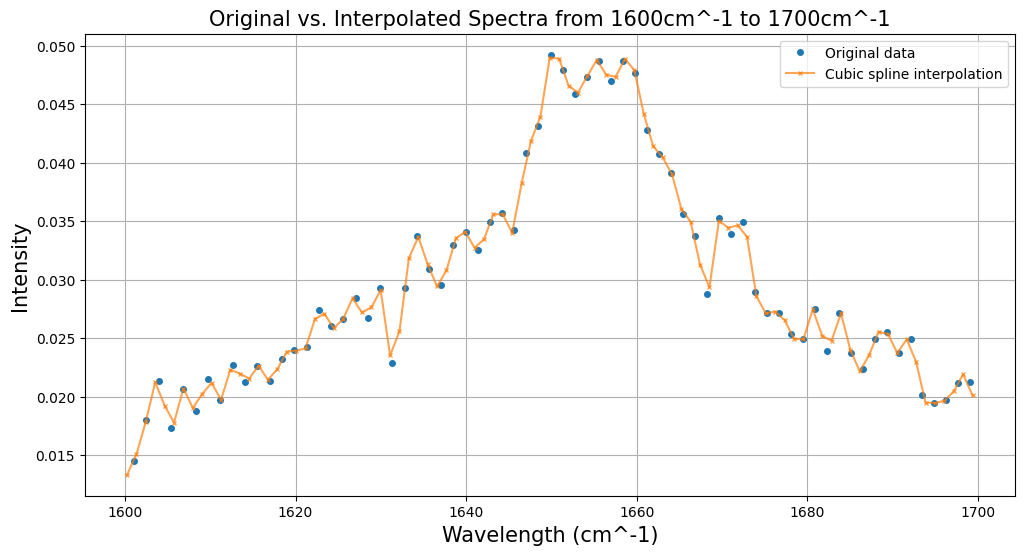

In [14]:
wavelength_range = (1600, 1700) # Changed to the global min/max
sample_idx = 0

training_sample = X_raw[sample_idx]
interpolated_sample = interpolated_spectra[sample_idx]

wavelengths_original, spectra_original = get_spectra_from_range(training_sample, asse_X_flat, wavelength_range)
wavelengths_interpolated, spectra_interpolated = get_spectra_from_range(interpolated_sample, new_wavelengths, wavelength_range)

plt.figure(figsize=(12,6))
plt.plot(wavelengths_original, spectra_original,
        'o', label='Original data', markersize=4) # Reduced markersize to better view numerous points
plt.plot(wavelengths_interpolated, spectra_interpolated,
          'x-', label='Cubic spline interpolation', alpha=0.7, markersize=3) # Restored 'x' marker for interpolated points

plt.xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
plt.ylabel('Intensity', fontsize=FONTSIZE_AXIS)
plt.title(f'Original vs. Interpolated Spectra from {wavelength_range[0]}cm^-1 to {wavelength_range[1]}cm^-1', fontsize=FONTSIZE_TITLE)
plt.legend()
plt.grid(True)
plt.show()

This plot is used to show normalization in Figure 3

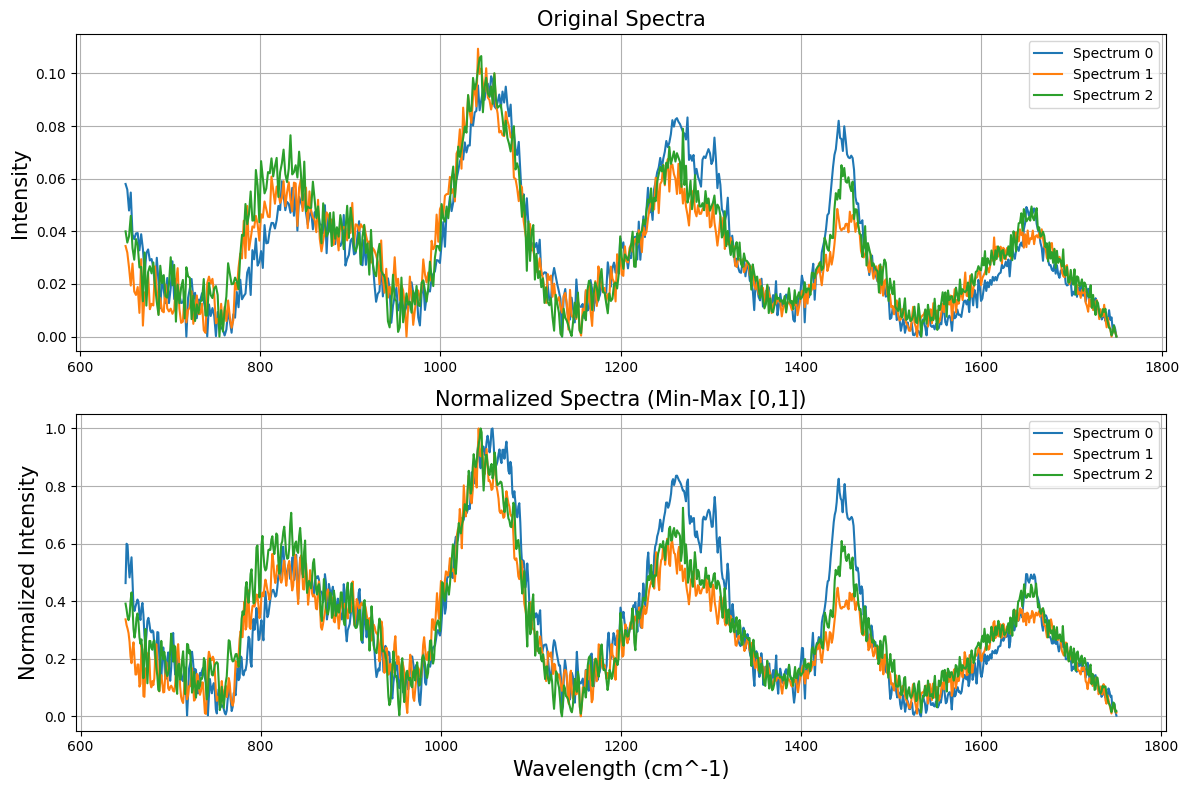

In [15]:
def plot_normalization_comparison(original_spectra, normalized_spectra, sample_indices=[0,1,2]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot original spectra
    for idx in sample_indices:
        ax1.plot(asse_X_flat, original_spectra[idx], label=f'Spectrum {idx}')
    ax1.set_title('Original Spectra', fontsize=FONTSIZE_TITLE)
    # ax1.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax1.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
    ax1.legend()
    ax1.grid(True)

    # Plot normalized spectra
    for idx in sample_indices:
        ax2.plot(new_wavelengths, normalized_spectra[idx], label=f'Spectrum {idx}')
    ax2.set_title('Normalized Spectra (Min-Max [0,1])', fontsize=FONTSIZE_TITLE)
    ax2.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax2.set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Plot comparison
plot_normalization_comparison(X_raw, normalized_spectra)

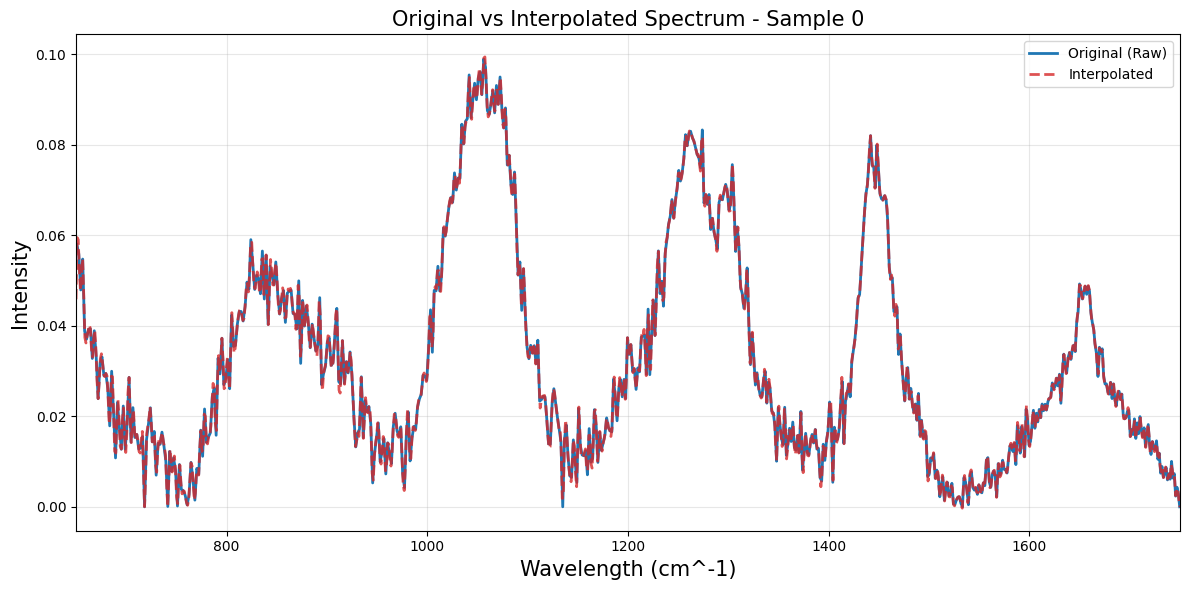

In [16]:
# Overlay of original and interpolated spectra to verify shape preservation
sample_idx = 0
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Original Spectrum
ax.plot(asse_X_flat, X_raw[sample_idx], color='tab:blue', label='Original (Raw)', linewidth=2)

# Plot Interpolated Spectrum
ax.plot(new_wavelengths, interpolated_spectra[sample_idx], color='tab:red', linestyle='--', alpha=0.8, label='Interpolated', linewidth=2)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Original vs Interpolated Spectrum - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()